* [GWTC-4 data zenodo](https://zenodo.org/records/16911563)

In [1]:
# imports
from popsummary.popresult import PopulationResult
import numpy as np
import matplotlib.pyplot as plt

# load in result file
filename = "/Users/phurailatpamhemantakumar/Downloads/analyses_BBH/BBHMassSpinRedshift_BrokenPowerLawTwoPeaks_GaussianComponentSpins_PowerLawRedshift.h5"
result = PopulationResult(fname=filename)

# retrieve  hyperparameter names
hyperparameters = result.get_metadata('hyperparameters')

# print out the hyperparameter names and their median values and 90% credible intervals
for hyper in hyperparameters:
    samples = result.get_hyperparameter_samples(hyperparameters=[hyper])
    median = np.median(samples)
    lower = np.percentile(samples, 5)   # 5th percentile for 90% CI lower bound
    upper = np.percentile(samples, 95)  # 95th percentile for 90% CI upper bound
    print(rf"{hyper}: ${median:.3f}_{{{lower-median:.3f}}}^{{{upper-median:.3f}}}$")

opening existing popsummary file: /Users/phurailatpamhemantakumar/Downloads/analyses_BBH/BBHMassSpinRedshift_BrokenPowerLawTwoPeaks_GaussianComponentSpins_PowerLawRedshift.h5
alpha_1: $1.728_{-1.787}^{1.153}$
alpha_2: $4.512_{-1.325}^{1.562}$
alpha_chi: $-0.062_{-0.031}^{0.055}$
amax: $1.000_{0.000}^{0.000}$
beta: $1.171_{-1.002}^{1.225}$
beta_chi: $-0.702_{-0.269}^{0.443}$
break_mass: $35.622_{-13.042}^{12.413}$
delta_m_1: $4.321_{-3.991}^{4.887}$
delta_m_2: $4.910_{-4.335}^{4.030}$
lam_0: $0.361_{-0.213}^{0.275}$
lam_1: $0.586_{-0.261}^{0.216}$
lamb: $3.166_{-0.997}^{0.941}$
ln_bf_0: $-36.403_{-1.154}^{1.110}$
ln_bf_1: $-36.101_{-0.853}^{0.797}$
ln_bf_10: $-35.787_{-0.876}^{0.814}$
ln_bf_100: $-38.437_{-0.708}^{0.682}$
ln_bf_101: $-37.826_{-0.585}^{0.575}$
ln_bf_102: $-36.963_{-0.591}^{0.552}$
ln_bf_103: $-31.140_{-0.730}^{0.699}$
ln_bf_104: $-36.988_{-0.875}^{0.860}$
ln_bf_105: $-39.816_{-0.923}^{0.886}$
ln_bf_106: $-36.219_{-0.960}^{0.909}$
ln_bf_107: $-36.187_{-0.775}^{0.725}$
ln_

In [2]:
result.get_hyperparameter_samples(hyperparameters=['mmax']).shape

(3962, 1)

Hyperparameter: alpha_1, Samples shape: (3962,)
Hyperparameter: alpha_2, Samples shape: (3962,)
Hyperparameter: break_mass, Samples shape: (3962,)
Hyperparameter: mpp_1, Samples shape: (3962,)
Hyperparameter: sigpp_1, Samples shape: (3962,)
Hyperparameter: mpp_2, Samples shape: (3962,)
Hyperparameter: sigpp_2, Samples shape: (3962,)
Hyperparameter: mlow_1, Samples shape: (3962,)
Hyperparameter: delta_m_1, Samples shape: (3962,)
Hyperparameter: lam_0, Samples shape: (3962,)
Hyperparameter: lam_1, Samples shape: (3962,)
Hyperparameter: beta, Samples shape: (3962,)
Hyperparameter: mlow_2, Samples shape: (3962,)
Hyperparameter: delta_m_2, Samples shape: (3962,)
Data shape for corner plot: (3962, 14)


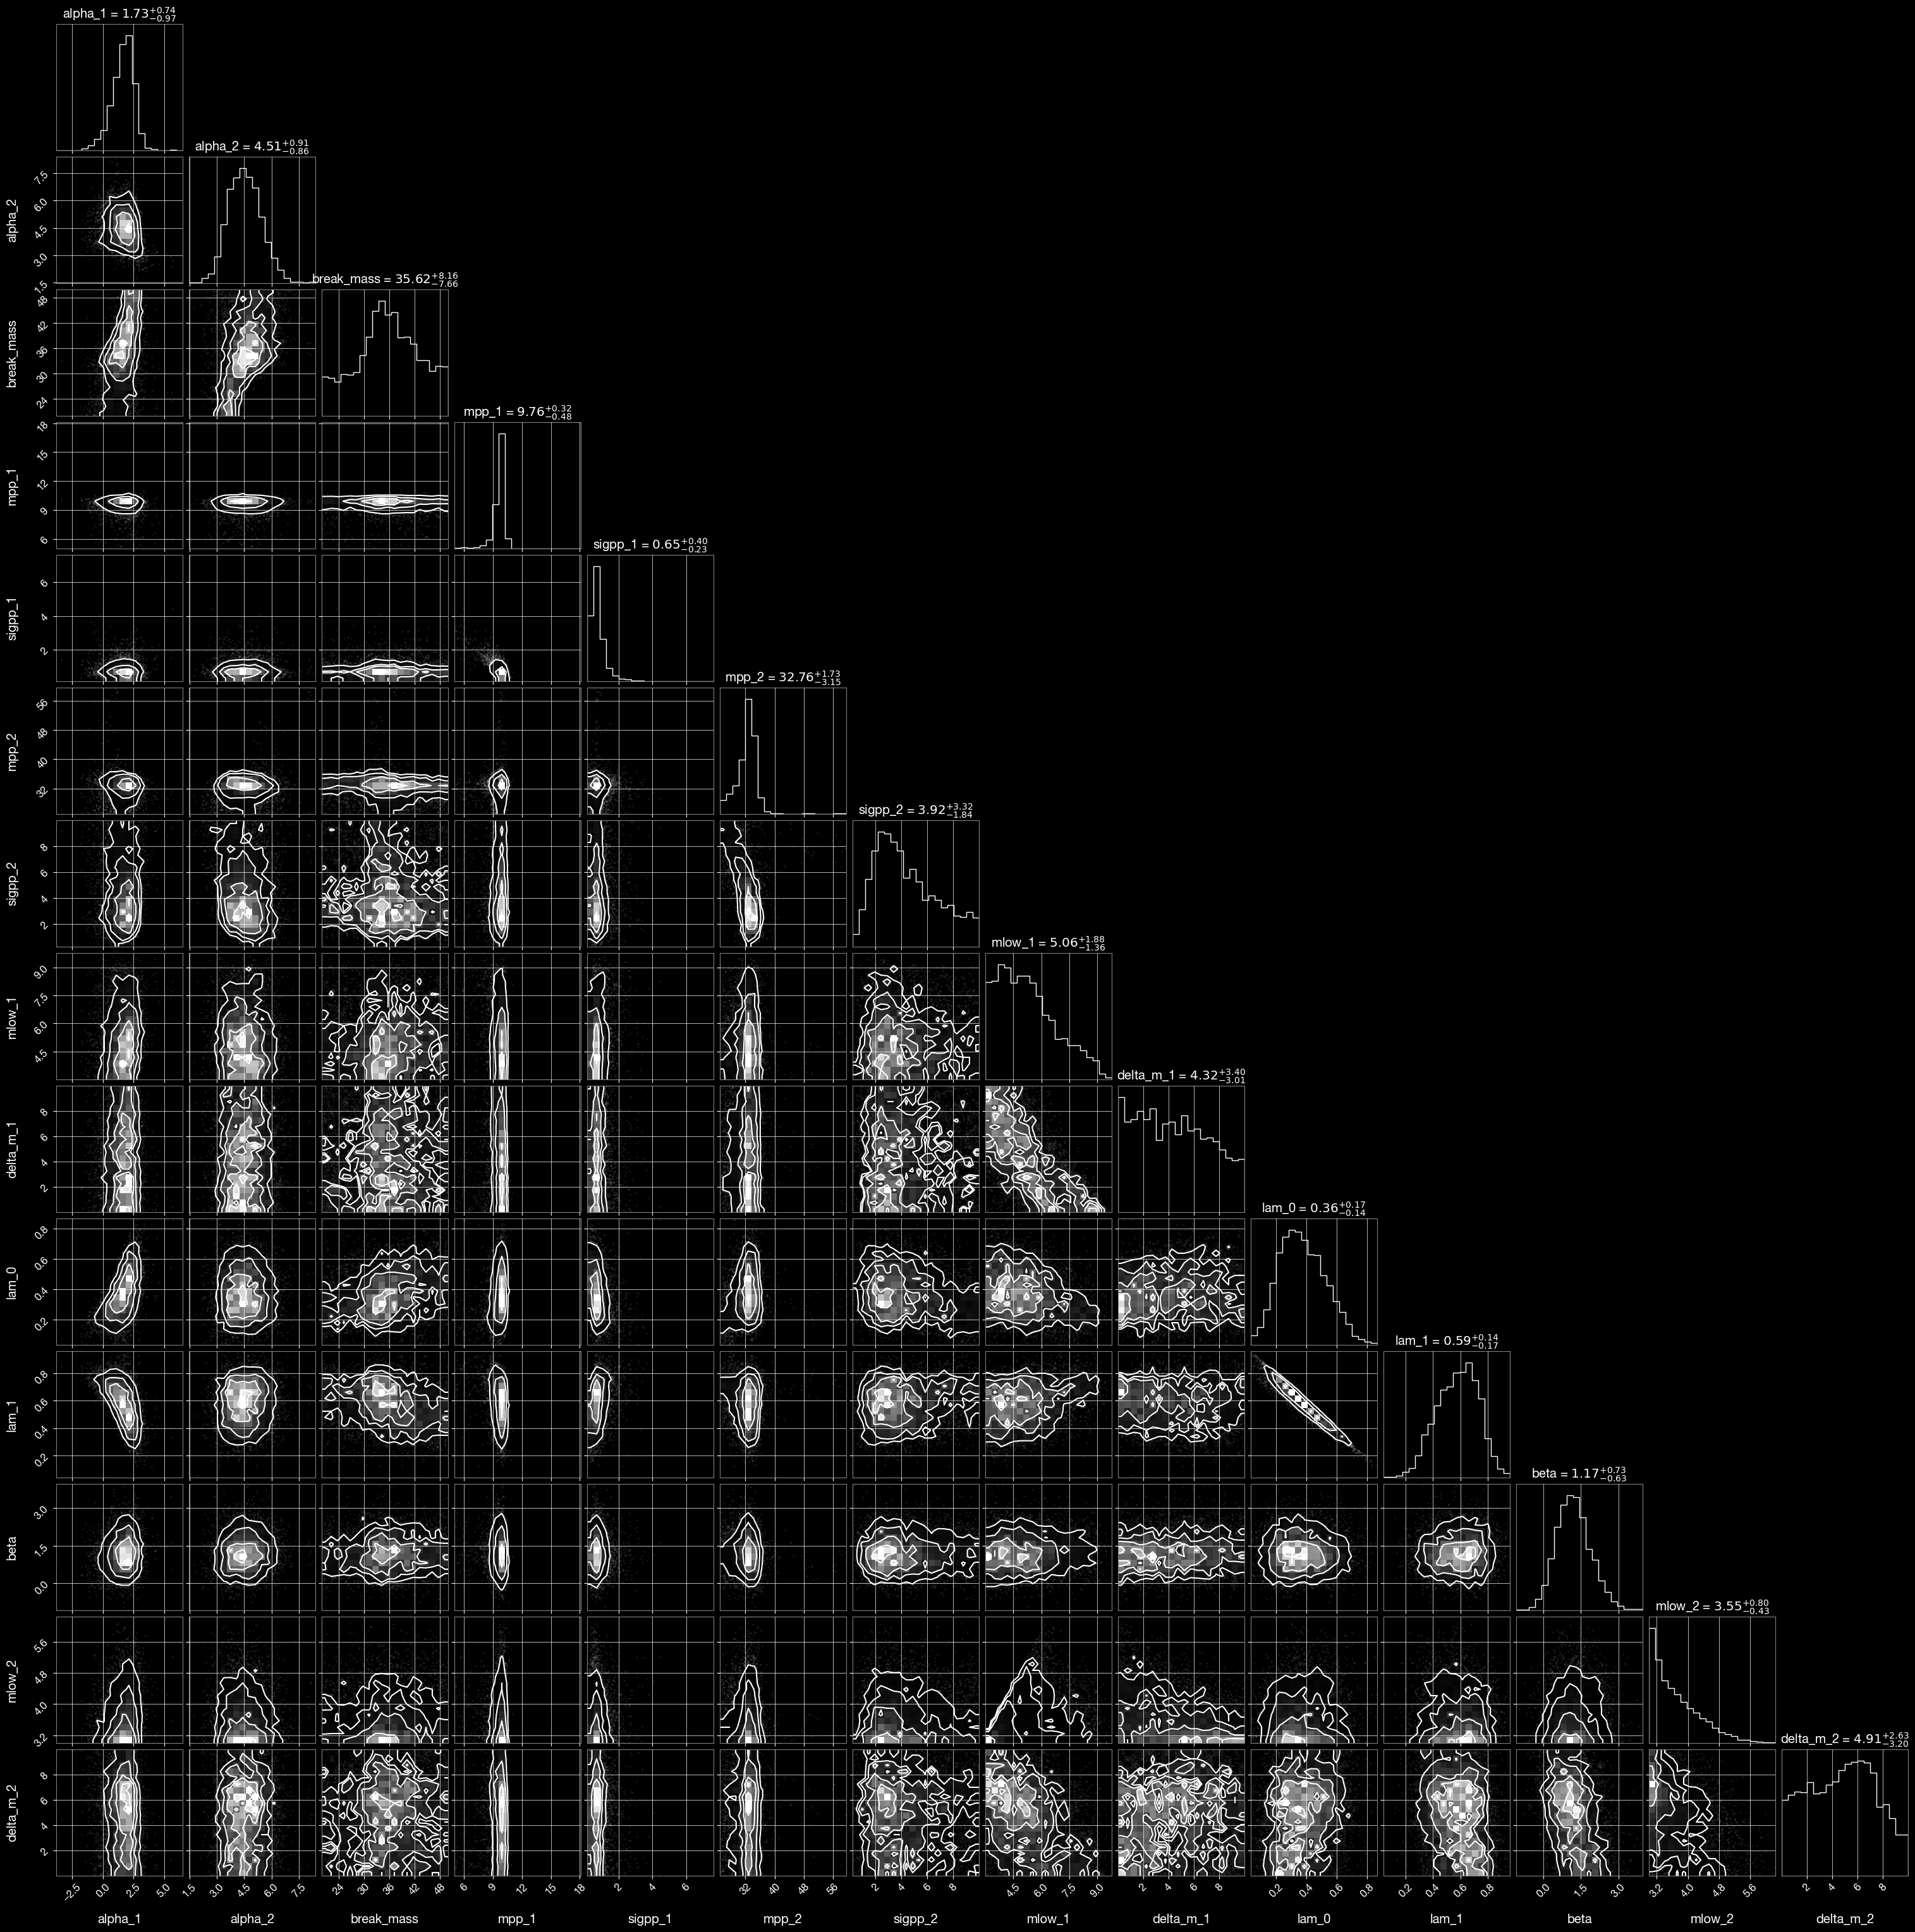

In [3]:
hyperparameters = ['alpha_1', 'alpha_2', 'break_mass', 'mpp_1', 'sigpp_1', 'mpp_2', 'sigpp_2', 'mlow_1', 'delta_m_1', 'lam_0', 'lam_1', 'beta', 'mlow_2', 'delta_m_2']

# make corner plot of the hyperparameters
import corner

samples_list = []
min_samples = np.inf
for hyper in hyperparameters:
    samples = result.get_hyperparameter_samples(hyperparameters=[hyper]).reshape(-1,)
    samples = np.asarray(samples).reshape(-1)  # ensure 1D
    print(f"Hyperparameter: {hyper}, Samples shape: {samples.shape}")
    min_samples = min(min_samples, samples.shape[0])
    samples_list.append(samples)

min_samples = int(min_samples)
data = np.column_stack([s[:min_samples] for s in samples_list])  # shape: (min_samples, n_hyperparameters)

print(f"Data shape for corner plot: {data.shape}")

figure = corner.corner(data, labels=hyperparameters, show_titles=True)
plt.show()

In [5]:
# save data in json file as a dict
# restrict value to 1000 samples for each hyperparameter to avoid large file size
from ler.utils import save_json

lower = np.percentile(data, 5, axis=0)
upper = np.percentile(data, 95, axis=0)
mask_90 = np.all((data >= lower) & (data <= upper), axis=1)
data_90 = data[mask_90]

# Use filtered posterior points from the previous cell
size = min(500, data_90.shape[0])
print(f"Number of samples within 90% credible interval: {data_90.shape[0]}")
idx = np.random.choice(data_90.shape[0], size=size, replace=False)
picked = data_90[idx]

hyper_dict = {hyper: picked[:, i] for i, hyper in enumerate(hyperparameters)}

save_json("broken_powerlaw_plus_2peaks_hyperparameters.json", hyper_dict)

Number of samples within 90% credible interval: 1186


In [4]:
from popsummary.popresult import PopulationResult
import numpy as np
import matplotlib.pyplot as plt

# load in result file
filename = "/Users/phurailatpamhemantakumar/Downloads/analyses_BBH/BBHMassSpinRedshift_BrokenPowerLawTwoPeaks_GaussianComponentSpins_PowerLawRedshift.h5"
result = PopulationResult(fname=filename)

from ler.utils import save_json

# hyperparameters = result.get_metadata('hyperparameters')
kappa = result.get_hyperparameter_samples(hyperparameters=['lamb'])
R0 = result.get_hyperparameter_samples(hyperparameters=['rate'])
# print size
print(f"Size of kappa samples: {kappa.shape}")
print(f"Size of R0 samples: {R0.shape}")

lower = np.percentile(kappa, 5, axis=0)
upper = np.percentile(kappa, 95, axis=0)
mask_90 = np.all((kappa >= lower) & (kappa <= upper), axis=1)
data_90 = kappa[mask_90]

# Use filtered posterior points from the previous cell
size = min(500, data_90.shape[0])
print(f"Number of samples within 90% credible interval: {data_90.shape[0]}")
idx = np.random.choice(data_90.shape[0], size=size, replace=False)
kappa = data_90[idx]
R0 = R0[idx]
hyper_dict = {"kappa": kappa, "R0": R0}


save_json("powerlaw_redshift_hyperparameters.json", hyper_dict)

opening existing popsummary file: /Users/phurailatpamhemantakumar/Downloads/analyses_BBH/BBHMassSpinRedshift_BrokenPowerLawTwoPeaks_GaussianComponentSpins_PowerLawRedshift.h5
Size of kappa samples: (3962, 1)
Size of R0 samples: (3962, 1)
Number of samples within 90% credible interval: 3564


# Compact binary mass models

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from ler.gw_source_population import prior_functions as pf

pf.available_prior_list()

['merger_rate_density_bbh_oguri2018_function',
 'merger_rate_density_bbh_popIII_ken2022_function',
 'merger_rate_density_madau_dickinson2014_function',
 'merger_rate_density_madau_dickinson_belczynski_ng_function',
 'merger_rate_density_bbh_primordial_ken2022_function',
 'sfr_madau_fragos2017_with_bbh_td',
 'sfr_madau_dickinson2014_with_bbh_td',
 'sfr_madau_fragos2017_with_bns_td',
 'sfr_madau_dickinson2014_with_bns_td',
 'sfr_madau_fragos2017',
 'sfr_madau_dickinson2014',
 'binary_masses_BBH_popIII_lognormal_rvs',
 'binary_masses_BBH_primordial_lognormal_rvs',
 'binary_masses_BNS_bimodal_rvs',
 'binary_masses_NSBH_broken_powerlaw_rvs',
 'binary_masses_BBH_powerlaw_gaussian_rvs']

In [ ]:
# Sample from posterior medians (GWTC-4.0 O4a analysis)
m1, m2 = pf.binary_masses_BBH_broken_powerlaw_plus_2peaks_rvs(
    size=100000,
    alpha1=1.728,        # Posterior median (alpha_1)
    alpha2=4.512,        # Posterior median (alpha_2)
    m_break=35.622,      # Posterior median (break_mass)
    m_min=5.0,              # Fixed (not inferred)
    m_max=300.0,            # Posterior median (mmax)
    delta_m=4.321,       # Posterior median (delta_m_1)
    mu1=9.8,                # Fixed (not inferred)
    sigma1=1.0,             # Fixed (not inferred)
    lam1=0.586,          # Posterior median (lam_1)
    mu2=32.7,               # Fixed (not inferred)
    sigma2=4.0,             # Fixed (not inferred)
    lam2=0.05,              # Fixed (not inferred)
    beta_q=1.171,        # Posterior median (beta)
    normalization_size=500
)

## BBH Population Hyperparameters (GWTC-4.0 O4a)

### Primary Mass Model (Broken Power Law + 2 Peaks)

<!-- alpha_1: $1.728_{-1.787}^{1.153}$
alpha_2: $4.512_{-1.325}^{1.562}$
alpha_chi: $-0.062_{-0.031}^{0.055}$
amax: $1.000_{0.000}^{0.000}$
beta: $1.171_{-1.002}^{1.225}$
beta_chi: $-0.702_{-0.269}^{0.443}$
break_mass: $35.622_{-13.042}^{12.413}$
delta_m_1: $4.321_{-3.991}^{4.887}$
delta_m_2: $4.910_{-4.335}^{4.030}$
lam_0: $0.361_{-0.213}^{0.275}$
lam_1: $0.586_{-0.261}^{0.216}$
lamb: $3.166_{-0.997}^{0.941}$
mlow_1: $5.059_{-1.840}^{3.183}$
mlow_2: $3.551_{-0.523}^{1.382}$
mmax: $300.000_{0.000}^{0.000}$
mpp_1: $9.764_{-1.283}^{0.496}$
mpp_2: $32.763_{-5.704}^{3.022}$
rate: $16.158_{-4.286}^{5.775}$
mu_chi: $0.085_{-0.077}^{0.136}$
sigma_chi: $0.330_{-0.081}^{0.077}$
mu_spin: $0.426_{-0.790}^{0.510}$
sigma_spin: $1.222_{-0.778}^{2.291}$ 
zeta: $0.652_{-0.535}^{0.315}$-->

| Symbol | Parameter | Median | Lower (5%) | Upper (95%) |
|--------|-----------|--------|------------|-------------|
| $\alpha_1$ | `alpha_1` | 1.728 | -0.058 | 2.882 |
| $\alpha_2$ | `alpha_2` | 4.512 | 3.186 | 6.074 |
| $m_{\rm break}$ | `break_mass` | 35.622 | 22.580 | 48.035 |
| $\mu_1$ | `mpp_1` | 9.764 | 8.481 | 10.260 |
| $\sigma_1$ | `sigpp_1` | 0.649 | 0.308 | 1.583 |
| $\mu_2$ | `mpp_2` | 32.763 | 27.059 | 35.785 |
| $\sigma_2$ | `sigpp_2` | 3.918 | 1.316 | 9.049 |
| $m_{1, {\rm low}}$ | `mlow_1` | 5.059 | 3.218 | 8.242 |
| $\delta_{{\rm m},1}$ | `delta_m_1` | 4.321 | 0.330 | 9.208 |
| $\lambda_0$ | `lam_0` | 0.361 | 0.148 | 0.636 |
| $\lambda_1$ | `lam_1` | 0.586 | 0.325 | 0.802 |
| $m_{\rm high}$ | `mmax` | 300.000 | 300.000 | 300.000 |

### Mass Ratio Model

| Symbol | Parameter | Median | Lower (5%) | Upper (95%) |
|--------|-----------|--------|------------|-------------|
| $\beta_q$ | `beta` | 1.171 | 0.169 | 2.396 |
| $m_{2, {\rm low}}$ | `mlow_2` | 3.551 | 3.028 | 4.934 |
| $\delta_{{\rm m},2}$ | `delta_m_2` | 4.910 | 0.575 | 8.940 |

### Redshift Model

| Symbol | Parameter | Median | Lower (5%) | Upper (95%) |
|--------|-----------|--------|------------|-------------|
| $R_0$ | `rate` | 16.158 | 11.872 | 21.933 |
| $\kappa$ | `lamb` | 3.166 | 2.169 | 4.107 |

### Spin Model

| Symbol | Parameter | Median | Lower (5%) | Upper (95%) |
|--------|-----------|--------|------------|-------------|
| $\mu_\chi$ | `mu_chi` | 0.085 | 0.008 | 0.221 |
| $\sigma_\chi$ | `sigma_chi` | 0.330 | 0.249 | 0.407 |
| $\mu_t$ | `mu_spin` | 0.426 | -0.364 | 0.936 |
| $\sigma_t$ | `sigma_spin` | 1.222 | 0.444 | 3.513 |
| $\zeta$ | `zeta` | 0.652 | 0.117 | 0.967 |


## Broken Power Law + Two Gaussian Peaks

In [31]:
import ler.gw_source_population.broken_powerlaw_plus_2peaks as bpl2p
import numpy as np
import matplotlib.pyplot as plt

## Function test, reproduce Figure 3 of GWTC-4.0

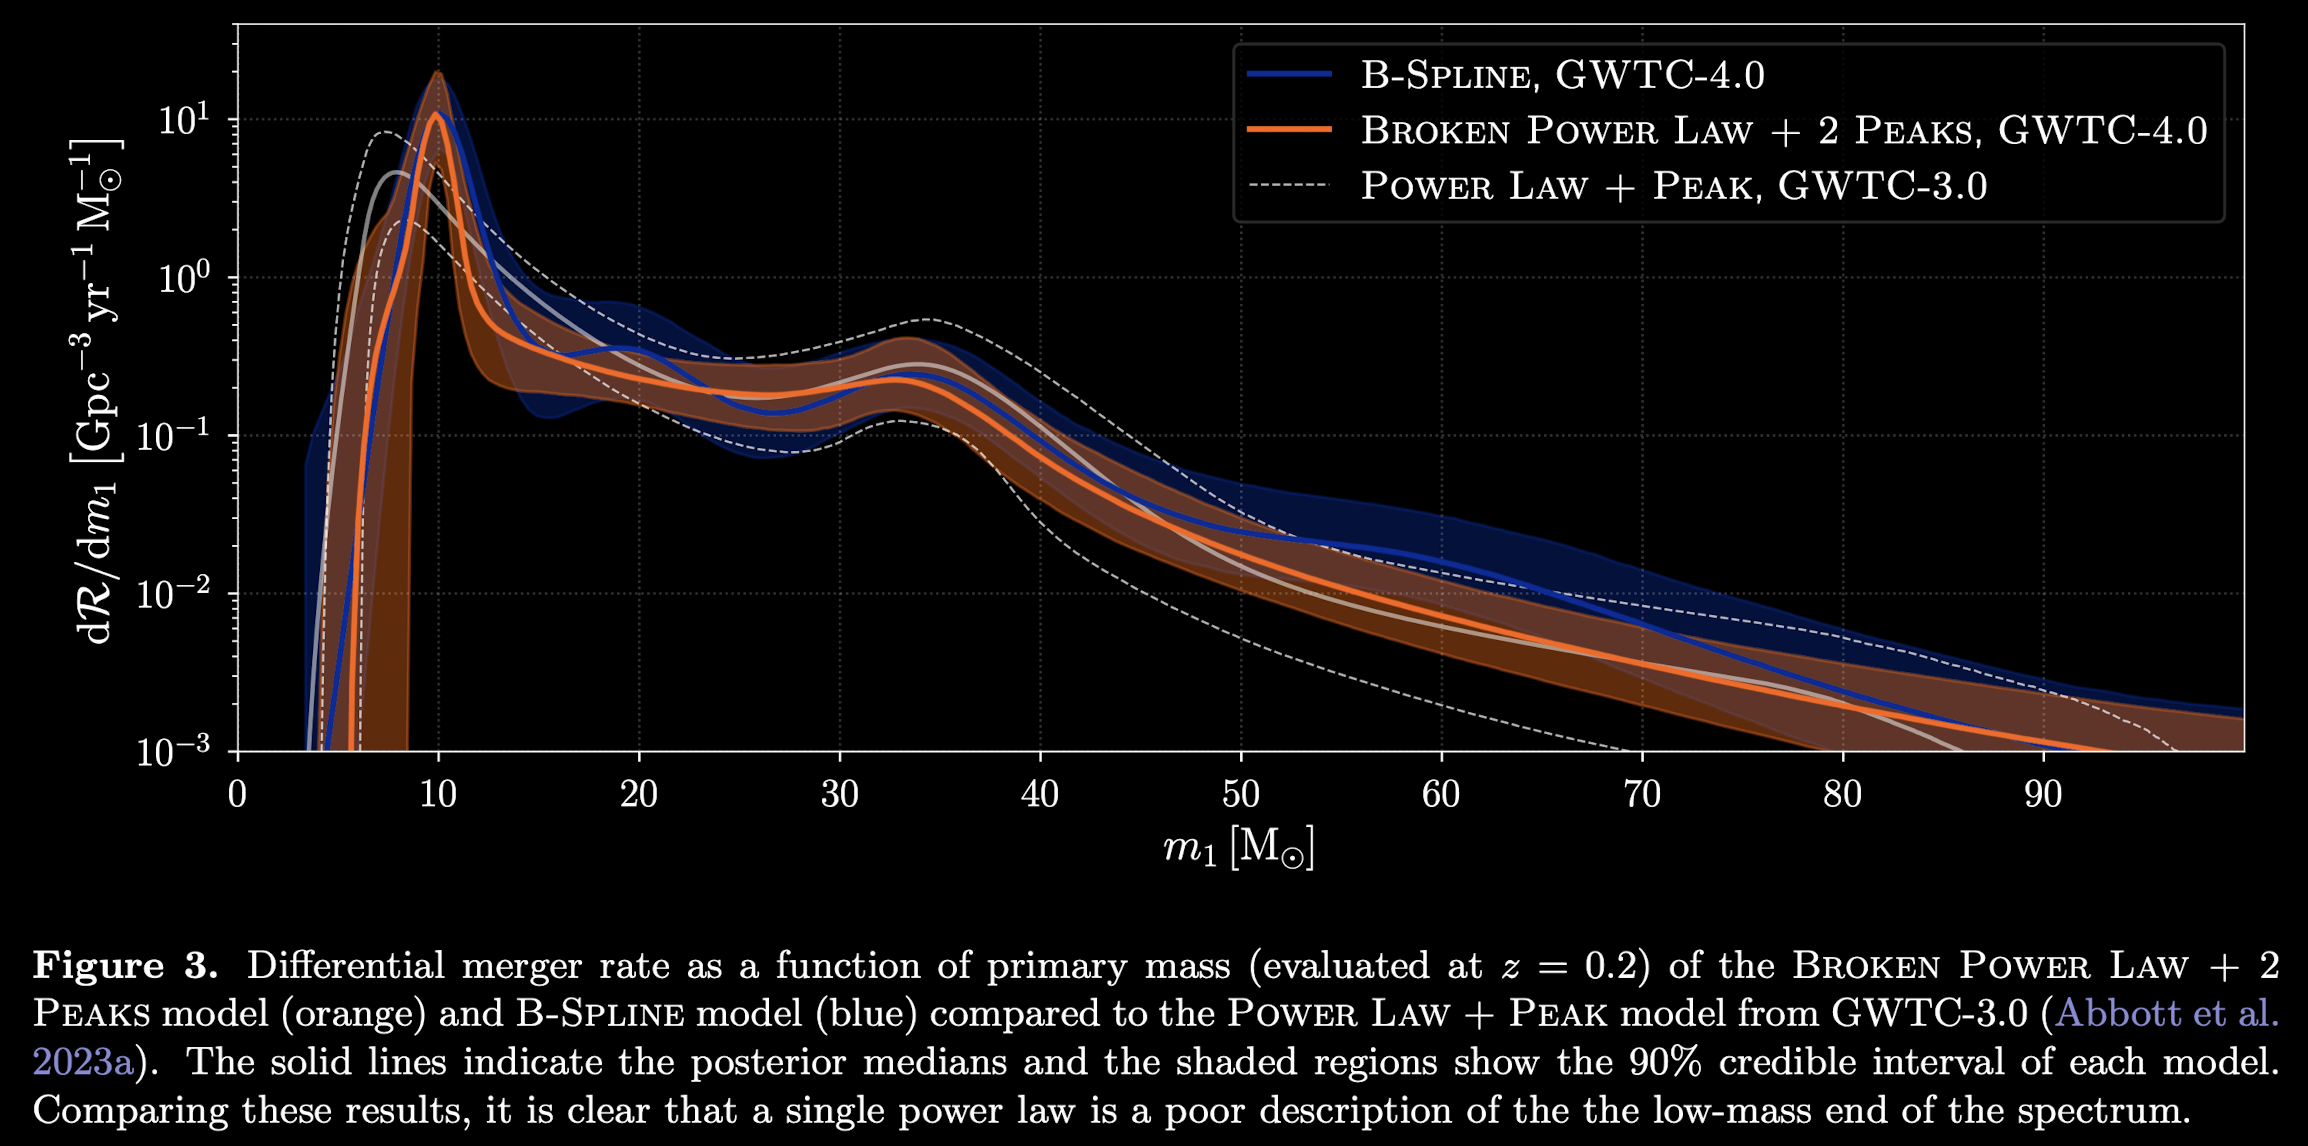

### Primary Mass Distribution

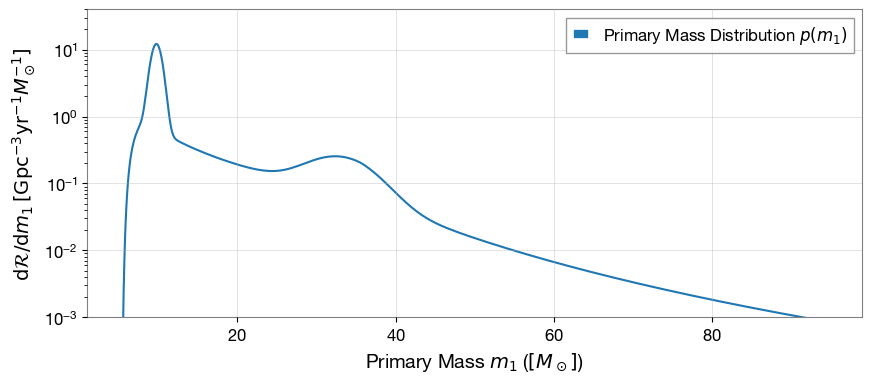

In [6]:
mlow_1 = 5.059
m1_arr = np.geomspace(mlow_1, 100.0, 200)
fn_m1 = bpl2p.broken_powerlaw_plus_2peaks_function(m1_arr)

plt.figure(figsize=(10, 4))
plt.plot(m1_arr, fn_m1, label='Primary Mass Distribution $p(m_1)$', color='C0')
plt.xlabel('Primary Mass $m_1$ ($[M_\\odot]$)', fontsize=14)
plt.ylabel('${\\rm d}{\\cal R}/{\\rm d} m_1\,[{\\rm Gpc}^{-3} {\\rm yr}^{-1} M_\\odot^{-1}]$', fontsize=14)
plt.yscale('log')
plt.ylim(1e-3, 40)
plt.xlim(1, 99)
plt.legend()
plt.grid(alpha=0.5)
plt.show()

In [32]:
# load data 
from ler.utils import get_param_from_json
data = get_param_from_json("broken_powerlaw_plus_2peaks_hyperparameters.json")
m1_fns = []
m1_arrs = []
size = 1000
idx = np.random.choice(len(data["lam_0"]), size=size, replace=False)
for i in idx:

    m1_arr = np.geomspace(data["mlow_1"][i], 300, 200)
    m1_fn = bpl2p.broken_powerlaw_plus_2peaks_function(
        m1_arr, 
        lam_0=data["lam_0"][i],
        lam_1=data["lam_1"][i],
        mpp_1=data["mpp_1"][i],
        sigpp_1=data["sigpp_1"][i],
        mpp_2=data["mpp_2"][i],
        sigpp_2=data["sigpp_2"][i],
        mlow_1=data["mlow_1"][i],
        delta_m_1=data["delta_m_1"][i],
        break_mass=data["break_mass"][i],
        alpha_1=data["alpha_1"][i],
        alpha_2=data["alpha_2"][i],
        mmax=300.0,
        normalization_size=500,
    )
    m1_fns.append(m1_fn)
    m1_arrs.append(m1_arr)
    

m1_fns = np.array(m1_fns)
m1_arrs = np.array(m1_arrs)

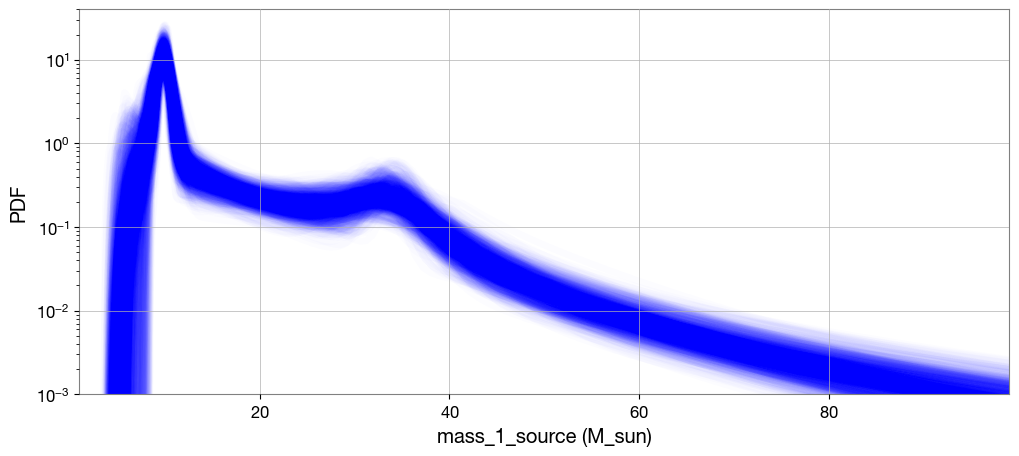

In [33]:
# plotting the distribution of m1 
# Plotting the distribution of m1 and m2
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
for i in range(size):
    plt.plot(m1_arrs[i], m1_fns[i], 'b-', alpha=0.01, linewidth=5)
plt.yscale('log')
plt.ylim(1e-3, 40)
plt.xlim(1, 99)
plt.xlabel("mass_1_source (M_sun)")
plt.ylabel("PDF")
plt.show()

### PDF

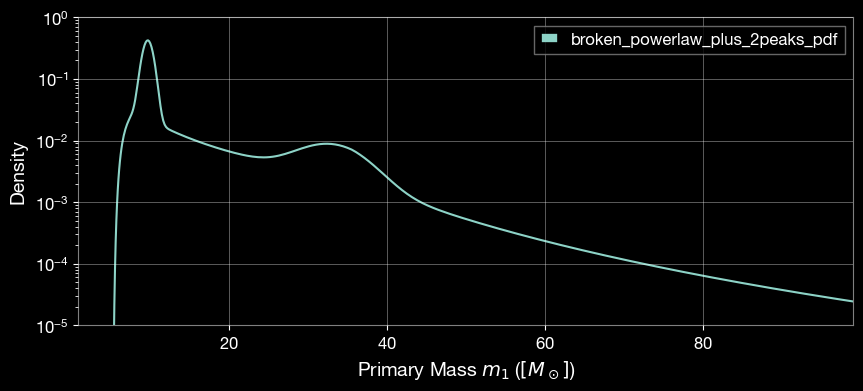

In [3]:
pdf_m1 = bpl2p.broken_powerlaw_plus_2peaks_pdf(m1_arr)
plt.figure(figsize=(10, 4))
plt.plot(m1_arr, pdf_m1, label='broken_powerlaw_plus_2peaks_pdf')
plt.xlabel('Primary Mass $m_1$ ($[M_\\odot]$)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.yscale('log')
plt.ylim(1e-5, 1.0)
plt.xlim(1, 99)
plt.legend()
plt.grid(alpha=0.5)
plt.show()

### CDF

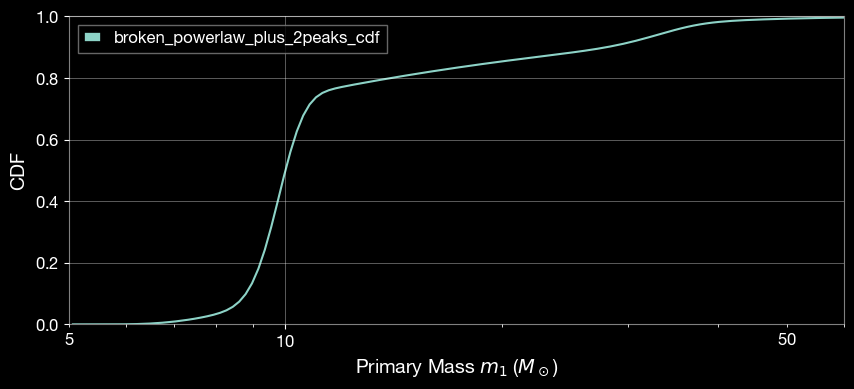

In [4]:
# cdf 
cdf_m1, m1_arr_cdf = bpl2p.broken_powerlaw_plus_2peaks_cdf(200)
plt.figure(figsize=(10, 4))
plt.plot(m1_arr_cdf, cdf_m1, label='broken_powerlaw_plus_2peaks_cdf')
plt.xlabel('Primary Mass $m_1$ ($M_\\odot$)', fontsize=14)
plt.ylabel('CDF', fontsize=14)
plt.xscale('log')
plt.ylim(0, 1.)
plt.xlim(5, 60)
plt.legend()
plt.grid(alpha=0.5)
plt.show()

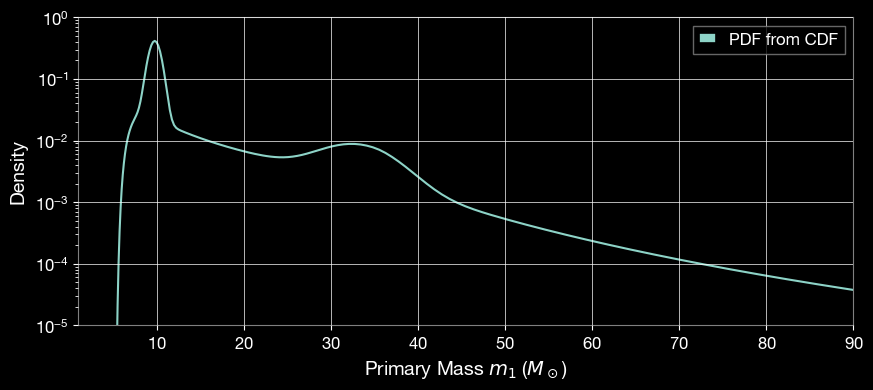

In [5]:
# reproduce pdf from cdf_m1, m1_arr_cdf
pdf_from_cdf = np.gradient(cdf_m1, m1_arr_cdf)
plt.figure(figsize=(10, 4))
plt.plot(m1_arr_cdf, pdf_from_cdf, label='PDF from CDF')
plt.xlabel('Primary Mass $m_1$ ($M_\\odot$)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.yscale('log')
plt.ylim(1e-5, 1.0)
plt.xlim(1, 90)
plt.legend()
plt.show()

### RVS

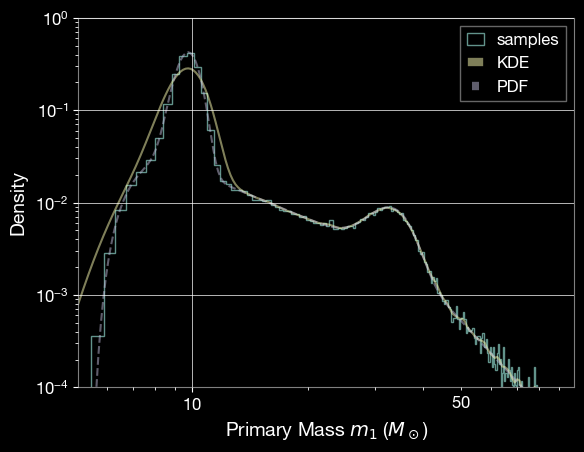

In [6]:
# sample
m1 = bpl2p.broken_powerlaw_plus_2peaks_rvs(size=200000)
m1 = m1[m1 < 90.0]  # filter out samples above 90 for better visualization

# create kde plot of m1
from scipy.stats import gaussian_kde
kde = gaussian_kde(m1, bw_method='scott')
m1_arr = np.geomspace(5.059, 99.0, 200)
m1_pdf = kde(m1_arr)

plt.hist(m1, bins=200, alpha=0.7, density=True, histtype='step', label='samples')
plt.plot(m1_arr, m1_pdf, '-', alpha=0.5, label='KDE')
# pdf_m1
pdf_m1 = bpl2p.broken_powerlaw_plus_2peaks_pdf(m1_arr)
plt.plot(m1_arr, pdf_m1, '--', alpha=0.5, label='PDF')
plt.xlabel('Primary Mass $m_1$ ($M_\\odot$)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.yscale('log')
plt.ylim(1e-4, 1.0)
plt.xscale('log')
plt.xlim(5.059, 99)
plt.legend()
plt.show()

## Mass-ratio

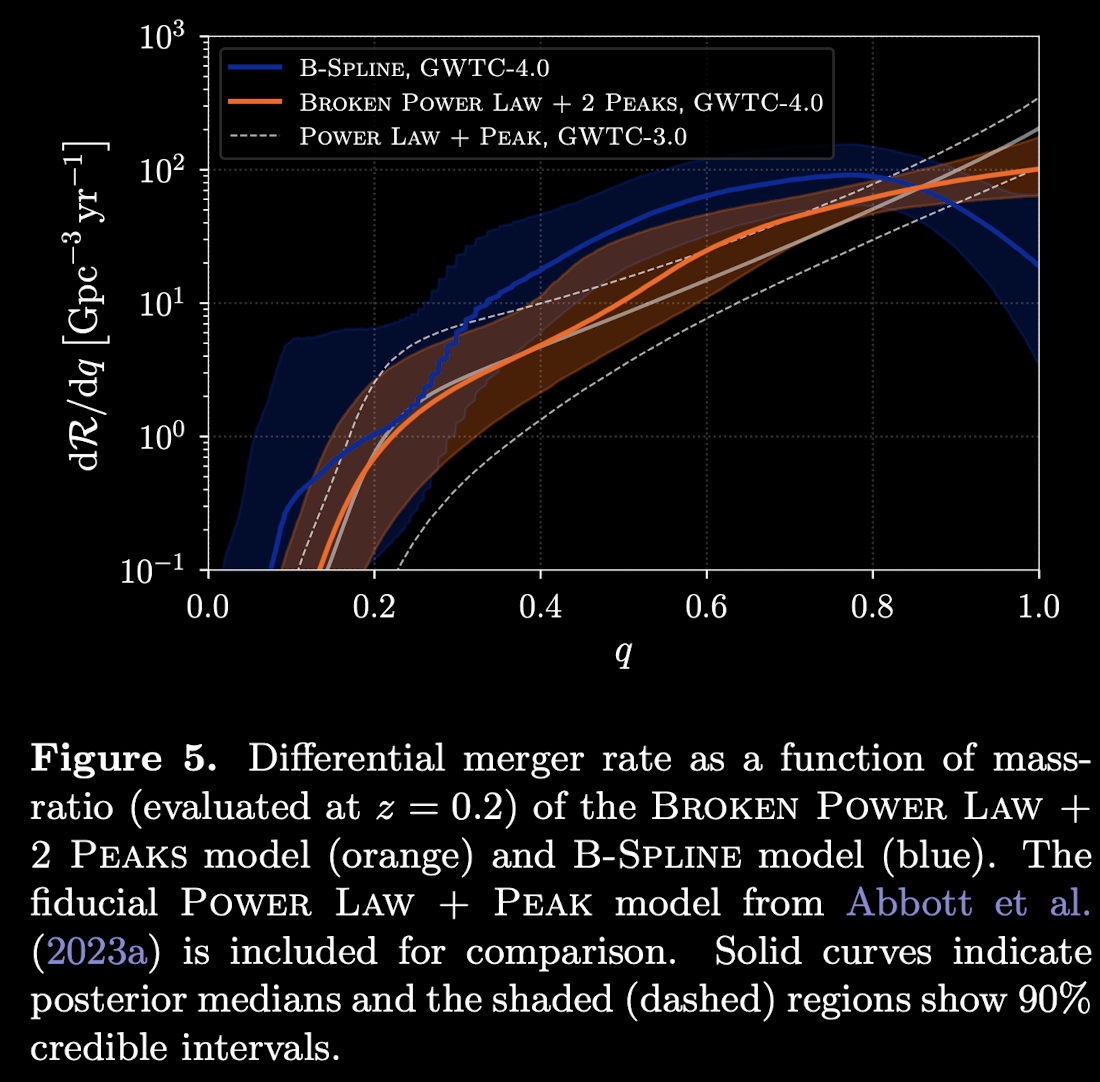

In [1]:
import ler.gw_source_population.broken_powerlaw_plus_2peaks as bpl2p
import numpy as np
import matplotlib.pyplot as plt

In [2]:
size = 20000
m1 = bpl2p.broken_powerlaw_plus_2peaks_rvs(size=size)

q_arr = bpl2p.mass_ratio_powerlaw_with_smoothing_rvs(m1)
q_arr_m10 = bpl2p.mass_ratio_powerlaw_with_smoothing_rvs(np.ones(size)*10.0)
q_arr_m35 = bpl2p.mass_ratio_powerlaw_with_smoothing_rvs(np.ones(size)*35.0)

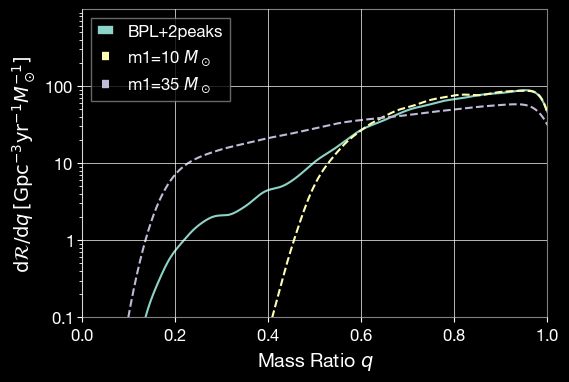

In [3]:
# create kde plot of q_arr
from scipy.stats import gaussian_kde
kde_q = gaussian_kde(q_arr, bw_method='scott')
q_arr_ = np.linspace(0, 1, 1000)
q_pdf = kde_q(q_arr_)
kde_q_m10 = gaussian_kde(q_arr_m10, bw_method='scott')
q_pdf_m10 = kde_q_m10(q_arr_)
kde_q_m35 = gaussian_kde(q_arr_m35, bw_method='scott')
q_pdf_m35 = kde_q_m35(q_arr_)

# rate
R0=16.158
kappa=3.166 
z_eval=0.2
R_z = R0 * (1.0 + z_eval) ** kappa

plt.figure(figsize=(6, 4))
plt.plot(q_arr_, R_z*q_pdf, label='BPL+2peaks')
plt.plot(q_arr_, R_z*q_pdf_m10, '--', label='m1=10 $M_\\odot$')
plt.plot(q_arr_, R_z*q_pdf_m35, '--', label='m1=35 $M_\\odot$')

plt.xlabel('Mass Ratio $q$', fontsize=14)
plt.ylabel('${\\rm d}{\\cal R}/{\\rm d} q \,[{\\rm Gpc}^{-3} {\\rm yr}^{-1} M_\\odot^{-1}]$', fontsize=14)
plt.yscale('log')
plt.ylim(1e-1, 1e3-10)
plt.xlim(0, 1)
plt.legend()
plt.show()

##